In [1]:
import pandas as pd 
from sklearn.impute import SimpleImputer
import seaborn as sns 
import matplotlib.pyplot as plt
from category_encoders import MEstimateEncoder, OrdinalEncoder, OneHotEncoder, TargetEncoder 
# from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix,classification_report
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
import joblib

In [2]:
data= pd.read_csv('weatherAUS.csv')
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
#percentage of missing values per column

(data.isnull().sum()/data.shape[0] * 100)


Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64

In [4]:
categorical_features= [feature for feature in data.columns if data[feature].dtype == 'O']
numerical_features= [feature for feature in data.columns if data[feature].dtype in ['float64', 'int64']]
discrete_features= [feature for feature in numerical_features if len(data[feature].unique())< 25 ]
continous_features= [feature for feature in numerical_features if len(data[feature].unique())>25]
print('CATEGORICAL FEATURES: {}'.format(len(categorical_features)))
print('NUMERICAL FEATURES: {}'.format(len(numerical_features)))
print('DISCRETE FEATURES: {}'.format(len(discrete_features)))
print('CONTINOUS FEATURES: {}'.format(len(continous_features)))

CATEGORICAL FEATURES: 7
NUMERICAL FEATURES: 16
DISCRETE FEATURES: 2
CONTINOUS FEATURES: 14


In [5]:
#replacing missing values for dicrete and categorical with its mode

si= SimpleImputer(strategy='most_frequent')
F1= si.fit_transform(data[discrete_features + categorical_features].values)

#replacing missing values for continous values with the mean
im= SimpleImputer(strategy= 'mean')

F2=si.fit_transform(data[continous_features])

data_1= pd.DataFrame(data=F1, columns=[discrete_features+ categorical_features])


In [6]:
data_2= pd.DataFrame(data= F2, columns=[continous_features])

In [7]:
data_1.head()

,Cloud9am,Cloud3pm,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,8.0,7.0,2008-12-01,Albury,W,W,WNW,No,No
1,7.0,7.0,2008-12-02,Albury,WNW,NNW,WSW,No,No
2,7.0,2.0,2008-12-03,Albury,WSW,W,WSW,No,No
3,7.0,7.0,2008-12-04,Albury,NE,SE,E,No,No
4,7.0,8.0,2008-12-05,Albury,W,ENE,NW,No,No


In [8]:
data_2.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,4.0,0.0,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8
1,7.4,25.1,0.0,4.0,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3
2,12.9,25.7,0.0,4.0,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2
3,9.2,28.0,0.0,4.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5
4,17.5,32.3,1.0,4.0,0.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7


In [9]:
#concatenating both data_1 and data_2
ndata=pd.concat([data_1, data_2], axis= 1)

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


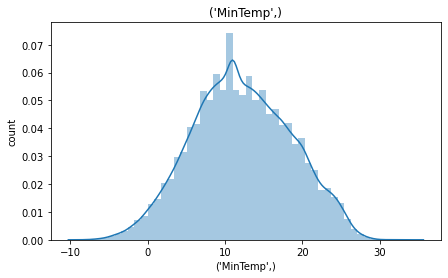

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


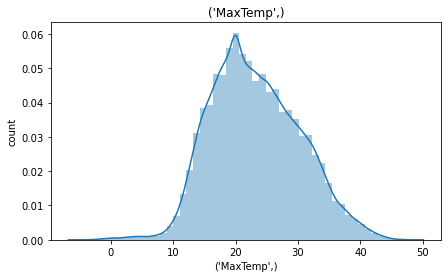

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


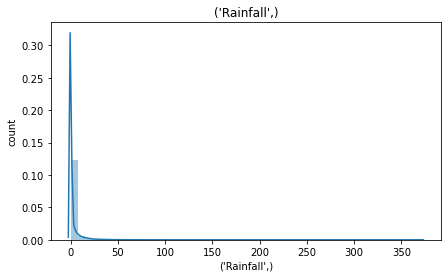

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


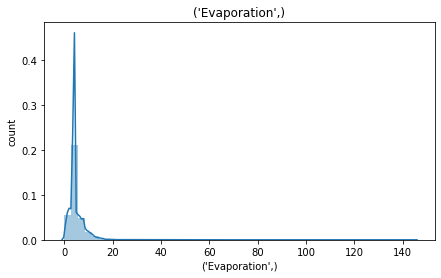

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


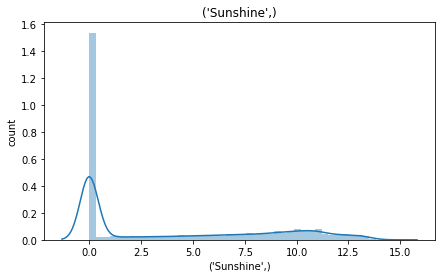

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


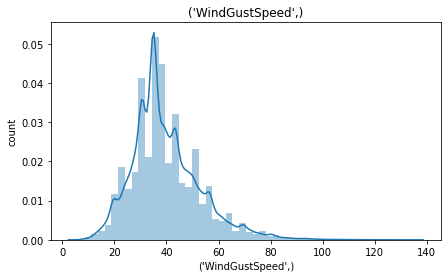

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


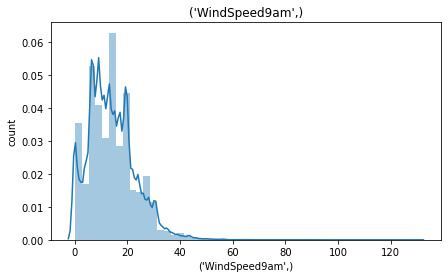

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


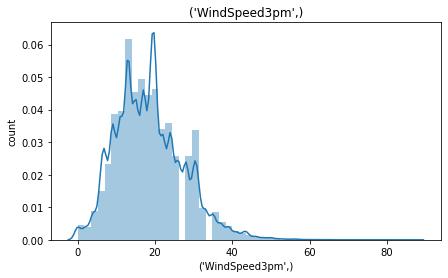

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


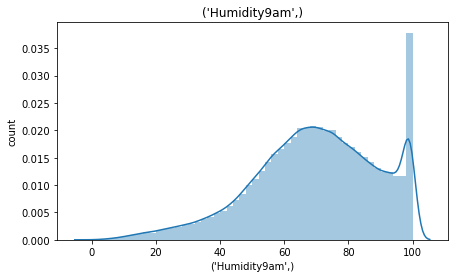

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


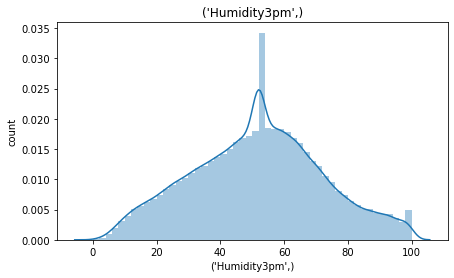

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


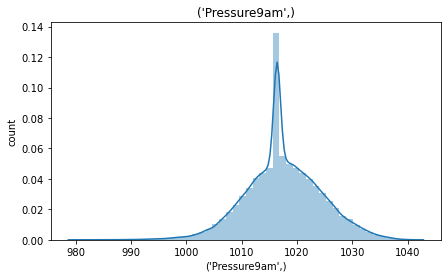

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


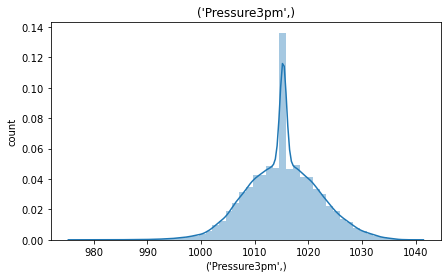

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


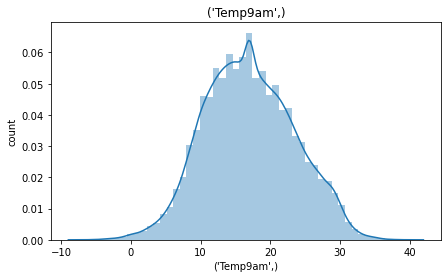

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


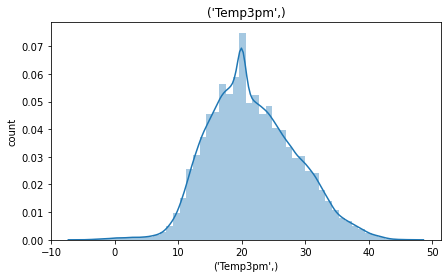

In [10]:

for feature in ndata[continous_features]:
    plt.figure(figsize=(7,4))
    sns.distplot(a= ndata[feature])
    plt.title(feature)
    plt.ylabel('count')
    plt.show()

<AxesSubplot:xlabel='None', ylabel='None'>

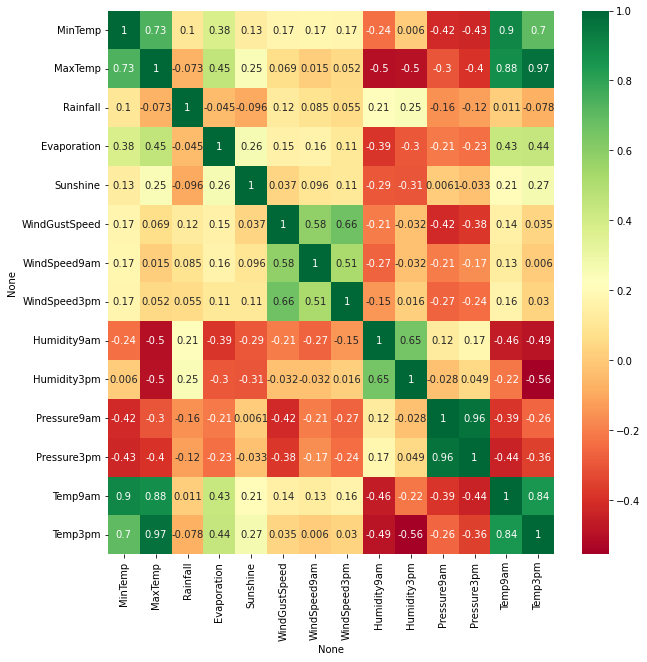

In [11]:
plt.figure(figsize=(10, 10))
corr= ndata.corr()
sns.heatmap(corr, annot= True, cmap='RdYlGn')

In [12]:
# low_cardinality_data= [feature for feature in ndata.columns if ndata[feature].dtype == 'O' and len(ndata[feature].unique())<= 3]

# mE= MEstimateEncoder()
# ndata['RainToday']= pd.get_dummies(ndata['RainToday'], drop_first= True)
# ndata['RainTomorrow']= pd.get_dummies(ndata['RainTomorrow'], drop_first= True)
# ndata

In [13]:
# oneHot= OneHotEncoder(drop_invariant= True, cols= [low_cardinality_data])
# oneHot.fit_transform(ndata.values)

In [14]:
ndata= pd.get_dummies(ndata, columns= ['RainToday', 'RainTomorrow'], drop_first= True)



C:\Users\user\AppData\Local\Temp\ipykernel_2836\3385349553.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ndata= pd.get_dummies(ndata, columns= ['RainToday', 'RainTomorrow'], drop_first= True)


In [15]:
ndata.head()

,"(Cloud9am,)","(Cloud3pm,)","(Date,)","(Location,)","(WindGustDir,)","(WindDir9am,)","(WindDir3pm,)","(MinTemp,)","(MaxTemp,)","(Rainfall,)",...,"(WindSpeed9am,)","(WindSpeed3pm,)","(Humidity9am,)","(Humidity3pm,)","(Pressure9am,)","(Pressure3pm,)","(Temp9am,)","(Temp3pm,)","('RainToday',)_Yes","('RainTomorrow',)_Yes"
0,8.0,7.0,2008-12-01,Albury,W,W,WNW,13.4,22.9,0.6,...,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0,0
1,7.0,7.0,2008-12-02,Albury,WNW,NNW,WSW,7.4,25.1,0.0,...,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0,0
2,7.0,2.0,2008-12-03,Albury,WSW,W,WSW,12.9,25.7,0.0,...,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0,0
3,7.0,7.0,2008-12-04,Albury,NE,SE,E,9.2,28.0,0.0,...,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0,0
4,7.0,8.0,2008-12-05,Albury,W,ENE,NW,17.5,32.3,1.0,...,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0,0


In [16]:
for features in discrete_features:
    print(len(data[features].unique()))

11
11


In [17]:
ndata.columns

Index([          ('Cloud9am',),           ('Cloud3pm',),
                     ('Date',),           ('Location',),
              ('WindGustDir',),         ('WindDir9am',),
               ('WindDir3pm',),            ('MinTemp',),
                  ('MaxTemp',),           ('Rainfall',),
              ('Evaporation',),           ('Sunshine',),
            ('WindGustSpeed',),       ('WindSpeed9am',),
             ('WindSpeed3pm',),        ('Humidity9am',),
              ('Humidity3pm',),        ('Pressure9am',),
              ('Pressure3pm',),            ('Temp9am',),
                  ('Temp3pm',),    '('RainToday',)_Yes',
       '('RainTomorrow',)_Yes'],
      dtype='object')

In [18]:
data.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [19]:
ndata.columns= ['Cloud9am','Cloud3pm','Date','Location','WindGustDir','WindDir9am','WindDir3pm', 'MinTemp','MaxTemp', 'Rainfall','Evaporation','Sunshine','WindGustSpeed','WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Temp9am','Temp3pm','RainToday','RainTomorrow']

In [20]:
categorical_cardinalities= [print(feature + ' ' 'cardinality :{}'.format(len(ndata[feature].unique()))) for 
                           feature in categorical_features if len(ndata[feature].unique())<200]

Location cardinality :49
WindGustDir cardinality :16
WindDir9am cardinality :16
WindDir3pm cardinality :16
RainToday cardinality :2
RainTomorrow cardinality :2


In [21]:
ndata.drop(columns=['Evaporation', 'Sunshine'])

,Cloud9am,Cloud3pm,Date,Location,WindGustDir,WindDir9am,WindDir3pm,MinTemp,MaxTemp,Rainfall,...,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,8.0,7.0,2008-12-01,Albury,W,W,WNW,13.4,22.9,0.6,...,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0,0
1,7.0,7.0,2008-12-02,Albury,WNW,NNW,WSW,7.4,25.1,0.0,...,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0,0
2,7.0,2.0,2008-12-03,Albury,WSW,W,WSW,12.9,25.7,0.0,...,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0,0
3,7.0,7.0,2008-12-04,Albury,NE,SE,E,9.2,28.0,0.0,...,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0,0
4,7.0,8.0,2008-12-05,Albury,W,ENE,NW,17.5,32.3,1.0,...,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,7.0,7.0,2017-06-21,Uluru,E,SE,ENE,2.8,23.4,0.0,...,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,0,0
145456,7.0,7.0,2017-06-22,Uluru,NNW,SE,N,3.6,25.3,0.0,...,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,0,0
145457,7.0,7.0,2017-06-23,Uluru,N,SE,WNW,5.4,26.9,0.0,...,9.0,9.0,53.0,24.0,1021.0,1016.8,12.5,26.1,0,0
145458,3.0,2.0,2017-06-24,Uluru,SE,SSE,N,7.8,27.0,0.0,...,13.0,7.0,51.0,24.0,1019.4,1016.5,15.1,26.0,0,0


In [22]:
ndata["Date"] = pd.to_datetime(ndata["Date"], format = "%Y-%m-%dT", errors = "coerce")

In [23]:
ndata["Date_month"] = ndata["Date"].dt.month
ndata["Date_day"] = ndata["Date"].dt.day

In [24]:
mE= MEstimateEncoder(m=6000)
for feature in ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']:
                ndata[feature]=mE.fit_transform(ndata[feature], ndata['RainTomorrow'])

In [25]:
import numpy as np
print('minimum: {:.3f}'.format(np.min(ndata['Location'])))
print('maximum: {:.3f}'.format(np.max(ndata['Location'])))

minimum: 0.168
maximum: 0.267


In [26]:
ndata= ndata.drop(columns=['Date'])

In [27]:
ndata['RainTomorrow']
ndata.head()

,Cloud9am,Cloud3pm,Location,WindGustDir,WindDir9am,WindDir3pm,MinTemp,MaxTemp,Rainfall,Evaporation,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Date_month,Date_day
0,8.0,7.0,0.213814,0.243469,0.240119,0.249756,13.4,22.9,0.6,4.0,...,71.0,22.0,1007.7,1007.1,16.9,21.8,0,0,12,1
1,7.0,7.0,0.213814,0.251886,0.267874,0.219608,7.4,25.1,0.0,4.0,...,44.0,25.0,1010.6,1007.8,17.2,24.3,0,0,12,2
2,7.0,2.0,0.213814,0.225621,0.240119,0.219608,12.9,25.7,0.0,4.0,...,38.0,30.0,1007.6,1008.7,21.0,23.2,0,0,12,3
3,7.0,7.0,0.213814,0.200554,0.183547,0.189599,9.2,28.0,0.0,4.0,...,45.0,16.0,1017.6,1012.8,18.1,26.5,0,0,12,4
4,7.0,8.0,0.213814,0.243469,0.193689,0.253790,17.5,32.3,1.0,4.0,...,82.0,33.0,1010.8,1006.0,17.8,29.7,0,0,12,5


<AxesSubplot:>

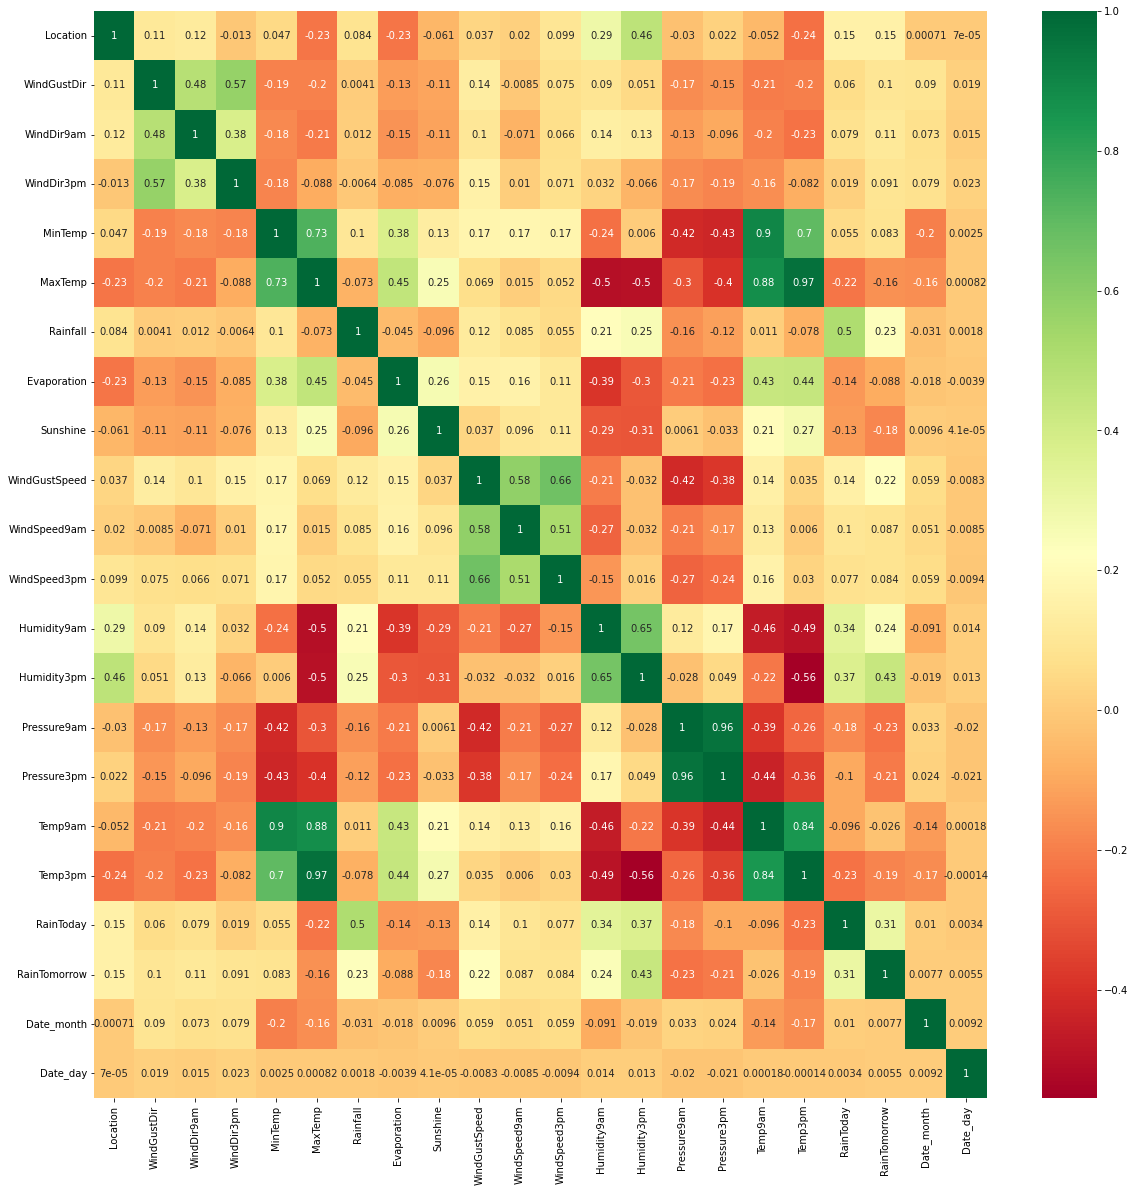

In [28]:
plt.figure(figsize=(20,20))

corr= ndata.corr()
sns.heatmap(corr, annot=True, cmap= 'RdYlGn')

In [29]:
df= ndata.copy()

y= ndata.pop('RainTomorrow')
X= ndata

In [30]:
X.head()

,Cloud9am,Cloud3pm,Location,WindGustDir,WindDir9am,WindDir3pm,MinTemp,MaxTemp,Rainfall,Evaporation,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,Date_month,Date_day
0,8.0,7.0,0.213814,0.243469,0.240119,0.249756,13.4,22.9,0.6,4.0,...,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0,12,1
1,7.0,7.0,0.213814,0.251886,0.267874,0.219608,7.4,25.1,0.0,4.0,...,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0,12,2
2,7.0,2.0,0.213814,0.225621,0.240119,0.219608,12.9,25.7,0.0,4.0,...,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0,12,3
3,7.0,7.0,0.213814,0.200554,0.183547,0.189599,9.2,28.0,0.0,4.0,...,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0,12,4
4,7.0,8.0,0.213814,0.243469,0.193689,0.253790,17.5,32.3,1.0,4.0,...,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0,12,5


In [31]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)
model= RandomForestClassifier(n_estimators= 50, max_depth= 12, verbose= 0)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=50)

In [32]:
predictions= model.predict(X_test)

trainnig score: 0.884
test score: 0.848


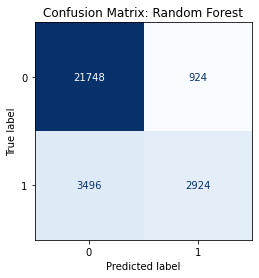

In [33]:
print('trainnig score: {:.3f}'.format(model.score(X_train, y_train)))
print('test score: {:.3f}'.format(model.score(X_test, y_test)))

cm= confusion_matrix(y_true=y_test, y_pred=predictions)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', colorbar= False)
plt.title('Confusion Matrix: Random Forest')
plt.show()

In [34]:
report = pd.DataFrame(data=classification_report(
    y_true=y_test, y_pred=predictions, output_dict=True))
report

,0,1,accuracy,macro avg,weighted avg
precision,0.861512,0.759875,0.848068,0.810693,0.839083
recall,0.959245,0.455452,0.848068,0.707348,0.848068
f1-score,0.907755,0.569536,0.848068,0.738646,0.833117
support,22672.000000,6420.000000,0.848068,29092.000000,29092.000000


In [35]:
cat = CatBoostClassifier(iterations=1000, eval_metric = "AUC")
cat.fit(X_train, y_train)

Learning rate set to 0.078532
0:	total: 214ms	remaining: 3m 34s
1:	total: 280ms	remaining: 2m 19s
2:	total: 337ms	remaining: 1m 51s
3:	total: 390ms	remaining: 1m 37s
4:	total: 457ms	remaining: 1m 30s
5:	total: 509ms	remaining: 1m 24s
6:	total: 553ms	remaining: 1m 18s
7:	total: 601ms	remaining: 1m 14s
8:	total: 648ms	remaining: 1m 11s
9:	total: 706ms	remaining: 1m 9s
10:	total: 749ms	remaining: 1m 7s
11:	total: 795ms	remaining: 1m 5s
12:	total: 836ms	remaining: 1m 3s
13:	total: 881ms	remaining: 1m 2s
14:	total: 946ms	remaining: 1m 2s
15:	total: 1s	remaining: 1m 1s
16:	total: 1.06s	remaining: 1m 1s
17:	total: 1.18s	remaining: 1m 4s
18:	total: 1.25s	remaining: 1m 4s
19:	total: 1.33s	remaining: 1m 5s
20:	total: 1.38s	remaining: 1m 4s
21:	total: 1.45s	remaining: 1m 4s
22:	total: 1.51s	remaining: 1m 4s
23:	total: 1.55s	remaining: 1m 3s
24:	total: 1.59s	remaining: 1m 2s
25:	total: 1.63s	remaining: 1m 1s
26:	total: 1.68s	remaining: 1m
27:	total: 1.73s	remaining: 1m
28:	total: 1.77s	remaining: 

240:	total: 12.1s	remaining: 38.2s
241:	total: 12.2s	remaining: 38.1s
242:	total: 12.2s	remaining: 38.1s
243:	total: 12.3s	remaining: 38s
244:	total: 12.3s	remaining: 37.9s
245:	total: 12.3s	remaining: 37.8s
246:	total: 12.4s	remaining: 37.8s
247:	total: 12.4s	remaining: 37.7s
248:	total: 12.5s	remaining: 37.7s
249:	total: 12.5s	remaining: 37.6s
250:	total: 12.6s	remaining: 37.6s
251:	total: 12.6s	remaining: 37.5s
252:	total: 12.7s	remaining: 37.4s
253:	total: 12.7s	remaining: 37.4s
254:	total: 12.8s	remaining: 37.3s
255:	total: 12.8s	remaining: 37.3s
256:	total: 12.9s	remaining: 37.2s
257:	total: 12.9s	remaining: 37.2s
258:	total: 13s	remaining: 37.2s
259:	total: 13s	remaining: 37.1s
260:	total: 13.1s	remaining: 37.1s
261:	total: 13.1s	remaining: 37s
262:	total: 13.2s	remaining: 37s
263:	total: 13.2s	remaining: 36.9s
264:	total: 13.3s	remaining: 36.8s
265:	total: 13.3s	remaining: 36.8s
266:	total: 13.4s	remaining: 36.7s
267:	total: 13.4s	remaining: 36.7s
268:	total: 13.5s	remaining: 3

477:	total: 23.3s	remaining: 25.4s
478:	total: 23.3s	remaining: 25.4s
479:	total: 23.4s	remaining: 25.3s
480:	total: 23.4s	remaining: 25.3s
481:	total: 23.5s	remaining: 25.2s
482:	total: 23.5s	remaining: 25.2s
483:	total: 23.6s	remaining: 25.1s
484:	total: 23.6s	remaining: 25.1s
485:	total: 23.7s	remaining: 25s
486:	total: 23.7s	remaining: 25s
487:	total: 23.8s	remaining: 24.9s
488:	total: 23.8s	remaining: 24.9s
489:	total: 23.9s	remaining: 24.8s
490:	total: 23.9s	remaining: 24.8s
491:	total: 24s	remaining: 24.7s
492:	total: 24s	remaining: 24.7s
493:	total: 24s	remaining: 24.6s
494:	total: 24.1s	remaining: 24.6s
495:	total: 24.1s	remaining: 24.5s
496:	total: 24.2s	remaining: 24.5s
497:	total: 24.2s	remaining: 24.4s
498:	total: 24.3s	remaining: 24.4s
499:	total: 24.3s	remaining: 24.3s
500:	total: 24.4s	remaining: 24.3s
501:	total: 24.4s	remaining: 24.2s
502:	total: 24.5s	remaining: 24.2s
503:	total: 24.5s	remaining: 24.1s
504:	total: 24.6s	remaining: 24.1s
505:	total: 24.6s	remaining: 2

719:	total: 34.7s	remaining: 13.5s
720:	total: 34.8s	remaining: 13.5s
721:	total: 34.8s	remaining: 13.4s
722:	total: 34.9s	remaining: 13.4s
723:	total: 34.9s	remaining: 13.3s
724:	total: 34.9s	remaining: 13.3s
725:	total: 35s	remaining: 13.2s
726:	total: 35s	remaining: 13.2s
727:	total: 35.1s	remaining: 13.1s
728:	total: 35.1s	remaining: 13s
729:	total: 35.1s	remaining: 13s
730:	total: 35.2s	remaining: 12.9s
731:	total: 35.2s	remaining: 12.9s
732:	total: 35.3s	remaining: 12.8s
733:	total: 35.3s	remaining: 12.8s
734:	total: 35.3s	remaining: 12.7s
735:	total: 35.4s	remaining: 12.7s
736:	total: 35.4s	remaining: 12.6s
737:	total: 35.5s	remaining: 12.6s
738:	total: 35.5s	remaining: 12.5s
739:	total: 35.6s	remaining: 12.5s
740:	total: 35.6s	remaining: 12.4s
741:	total: 35.6s	remaining: 12.4s
742:	total: 35.7s	remaining: 12.3s
743:	total: 35.8s	remaining: 12.3s
744:	total: 35.8s	remaining: 12.3s
745:	total: 35.9s	remaining: 12.2s
746:	total: 35.9s	remaining: 12.2s
747:	total: 35.9s	remaining:

959:	total: 46.1s	remaining: 1.92s
960:	total: 46.1s	remaining: 1.87s
961:	total: 46.2s	remaining: 1.82s
962:	total: 46.2s	remaining: 1.78s
963:	total: 46.3s	remaining: 1.73s
964:	total: 46.3s	remaining: 1.68s
965:	total: 46.4s	remaining: 1.63s
966:	total: 46.4s	remaining: 1.58s
967:	total: 46.5s	remaining: 1.54s
968:	total: 46.5s	remaining: 1.49s
969:	total: 46.6s	remaining: 1.44s
970:	total: 46.6s	remaining: 1.39s
971:	total: 46.7s	remaining: 1.34s
972:	total: 46.7s	remaining: 1.3s
973:	total: 46.8s	remaining: 1.25s
974:	total: 46.8s	remaining: 1.2s
975:	total: 46.9s	remaining: 1.15s
976:	total: 46.9s	remaining: 1.1s
977:	total: 47s	remaining: 1.06s
978:	total: 47s	remaining: 1.01s
979:	total: 47s	remaining: 960ms
980:	total: 47.1s	remaining: 912ms
981:	total: 47.1s	remaining: 864ms
982:	total: 47.2s	remaining: 816ms
983:	total: 47.2s	remaining: 768ms
984:	total: 47.3s	remaining: 720ms
985:	total: 47.3s	remaining: 672ms
986:	total: 47.4s	remaining: 624ms
987:	total: 47.4s	remaining: 

In [36]:
cat_pred= cat.predict(X_test)
MMsc= MinMaxScaler()



trainnig score: 0.889
test score: 0.861


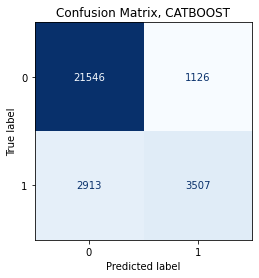

In [37]:
print('trainnig score: {:.3f}'.format(cat.score(X_train, y_train)))
print('test score: {:.3f}'.format(cat.score(X_test, y_test)))

cm= confusion_matrix(y_true=y_test, y_pred=cat_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', colorbar= False)
plt.title('Confusion Matrix, CATBOOST')
plt.show()

In [38]:
xgb= XGBClassifier()
xgb.fit(X_train.values, y_train.values)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [39]:
xgb_pd=xgb.predict(X_test.values)

trainnig score: 0.886
test score: 0.857


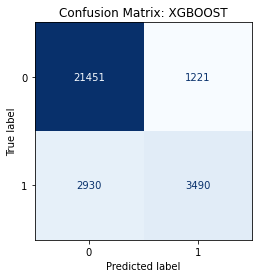

In [40]:
print('trainnig score: {:.3f}'.format(xgb.score(X_train.values, y_train.values)))
print('test score: {:.3f}'.format(xgb.score(X_test.values, y_test.values)))

cm= confusion_matrix(y_true=y_test.values, y_pred=xgb_pd)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', colorbar= False)
plt.title('Confusion Matrix: XGBOOST')
plt.show()

In [41]:
# svc= SVC(C= 100)
# svc.fit(X_train, y_train.values)

In [42]:
# svc_pred= svc.predict(X_test)

In [43]:
# print('trainnig score: {:.3f}'.format(svc.score(X_train.values, y_train.values)))
# print('test score: {:.3f}'.format(svc.score(X_test.values, y_test.values)))

# cm= confusion_matrix(y_true=y_test.values, y_pred=svc_pred)
# ConfusionMatrixDisplay(cm).plot(cmap='Blues', colorbar= False)
# plt.title('Confusion Matrix: XGBOOST')
# plt.show()

C:\Users\user\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\user\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


trainnig score: 0.839
test score: 0.837


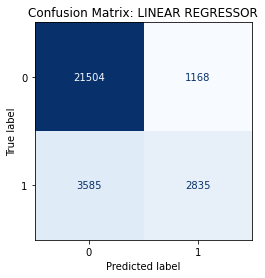

In [44]:
regressor= LogisticRegression()
regressor.fit(X_train,y_train)
linear_predict= regressor.predict(X_test)

print('trainnig score: {:.3f}'.format(regressor.score(X_train.values, y_train.values)))
print('test score: {:.3f}'.format(regressor.score(X_test.values, y_test.values)))

cm= confusion_matrix(y_true=y_test, y_pred=linear_predict)
ConfusionMatrixDisplay(cm).plot(cmap='Blues', colorbar= False)
plt.title('Confusion Matrix: LINEAR REGRESSOR')
plt.show()

In [50]:
from sklearn.ensemble import StackingClassifier

estimators=[
    ('xgb', xgb),
#     ('regressor', regressor),
    ('cat', cat),
#     ('model', model)
]

stack_model= StackingClassifier(estimators= estimators, final_estimator= LogisticRegression())

stack_model.fit(X_train.values, y_train.values)

Learning rate set to 0.078532
0:	total: 55.8ms	remaining: 55.8s
1:	total: 108ms	remaining: 53.8s
2:	total: 161ms	remaining: 53.5s
3:	total: 217ms	remaining: 54s
4:	total: 269ms	remaining: 53.5s
5:	total: 322ms	remaining: 53.3s
6:	total: 375ms	remaining: 53.1s
7:	total: 428ms	remaining: 53.1s
8:	total: 481ms	remaining: 53s
9:	total: 530ms	remaining: 52.4s
10:	total: 583ms	remaining: 52.4s
11:	total: 631ms	remaining: 52s
12:	total: 683ms	remaining: 51.9s
13:	total: 736ms	remaining: 51.8s
14:	total: 793ms	remaining: 52.1s
15:	total: 849ms	remaining: 52.2s
16:	total: 929ms	remaining: 53.7s
17:	total: 988ms	remaining: 53.9s
18:	total: 1.04s	remaining: 53.9s
19:	total: 1.1s	remaining: 53.9s
20:	total: 1.15s	remaining: 53.7s
21:	total: 1.2s	remaining: 53.4s
22:	total: 1.26s	remaining: 53.4s
23:	total: 1.31s	remaining: 53.3s
24:	total: 1.36s	remaining: 53.1s
25:	total: 1.42s	remaining: 53s
26:	total: 1.47s	remaining: 53s
27:	total: 1.52s	remaining: 52.9s
28:	total: 1.58s	remaining: 52.9s
29:	t

239:	total: 11.8s	remaining: 37.5s
240:	total: 11.9s	remaining: 37.4s
241:	total: 11.9s	remaining: 37.4s
242:	total: 12s	remaining: 37.3s
243:	total: 12s	remaining: 37.3s
244:	total: 12.1s	remaining: 37.2s
245:	total: 12.1s	remaining: 37.2s
246:	total: 12.2s	remaining: 37.2s
247:	total: 12.2s	remaining: 37.1s
248:	total: 12.3s	remaining: 37.1s
249:	total: 12.4s	remaining: 37.1s
250:	total: 12.4s	remaining: 37s
251:	total: 12.5s	remaining: 37s
252:	total: 12.5s	remaining: 36.9s
253:	total: 12.6s	remaining: 36.9s
254:	total: 12.6s	remaining: 36.9s
255:	total: 12.7s	remaining: 36.8s
256:	total: 12.7s	remaining: 36.8s
257:	total: 12.8s	remaining: 36.8s
258:	total: 12.8s	remaining: 36.7s
259:	total: 12.9s	remaining: 36.7s
260:	total: 12.9s	remaining: 36.6s
261:	total: 13s	remaining: 36.6s
262:	total: 13s	remaining: 36.6s
263:	total: 13.1s	remaining: 36.5s
264:	total: 13.1s	remaining: 36.5s
265:	total: 13.2s	remaining: 36.4s
266:	total: 13.3s	remaining: 36.4s
267:	total: 13.3s	remaining: 36.

476:	total: 23.4s	remaining: 25.7s
477:	total: 23.5s	remaining: 25.7s
478:	total: 23.5s	remaining: 25.6s
479:	total: 23.6s	remaining: 25.6s
480:	total: 23.6s	remaining: 25.5s
481:	total: 23.7s	remaining: 25.5s
482:	total: 23.8s	remaining: 25.4s
483:	total: 23.8s	remaining: 25.4s
484:	total: 23.8s	remaining: 25.3s
485:	total: 23.9s	remaining: 25.3s
486:	total: 24s	remaining: 25.2s
487:	total: 24s	remaining: 25.2s
488:	total: 24.1s	remaining: 25.1s
489:	total: 24.1s	remaining: 25.1s
490:	total: 24.2s	remaining: 25s
491:	total: 24.2s	remaining: 25s
492:	total: 24.3s	remaining: 24.9s
493:	total: 24.3s	remaining: 24.9s
494:	total: 24.4s	remaining: 24.8s
495:	total: 24.4s	remaining: 24.8s
496:	total: 24.5s	remaining: 24.8s
497:	total: 24.5s	remaining: 24.7s
498:	total: 24.6s	remaining: 24.7s
499:	total: 24.6s	remaining: 24.6s
500:	total: 24.7s	remaining: 24.6s
501:	total: 24.7s	remaining: 24.5s
502:	total: 24.8s	remaining: 24.5s
503:	total: 24.8s	remaining: 24.4s
504:	total: 24.9s	remaining:

717:	total: 35.6s	remaining: 14s
718:	total: 35.6s	remaining: 13.9s
719:	total: 35.7s	remaining: 13.9s
720:	total: 35.7s	remaining: 13.8s
721:	total: 35.8s	remaining: 13.8s
722:	total: 35.8s	remaining: 13.7s
723:	total: 35.9s	remaining: 13.7s
724:	total: 35.9s	remaining: 13.6s
725:	total: 35.9s	remaining: 13.6s
726:	total: 36s	remaining: 13.5s
727:	total: 36s	remaining: 13.5s
728:	total: 36.1s	remaining: 13.4s
729:	total: 36.1s	remaining: 13.4s
730:	total: 36.1s	remaining: 13.3s
731:	total: 36.2s	remaining: 13.2s
732:	total: 36.2s	remaining: 13.2s
733:	total: 36.3s	remaining: 13.1s
734:	total: 36.3s	remaining: 13.1s
735:	total: 36.3s	remaining: 13s
736:	total: 36.4s	remaining: 13s
737:	total: 36.4s	remaining: 12.9s
738:	total: 36.5s	remaining: 12.9s
739:	total: 36.5s	remaining: 12.8s
740:	total: 36.6s	remaining: 12.8s
741:	total: 36.6s	remaining: 12.7s
742:	total: 36.7s	remaining: 12.7s
743:	total: 36.8s	remaining: 12.7s
744:	total: 36.8s	remaining: 12.6s
745:	total: 36.9s	remaining: 1

954:	total: 47.6s	remaining: 2.24s
955:	total: 47.7s	remaining: 2.19s
956:	total: 47.7s	remaining: 2.15s
957:	total: 47.8s	remaining: 2.1s
958:	total: 47.8s	remaining: 2.04s
959:	total: 47.9s	remaining: 2s
960:	total: 47.9s	remaining: 1.95s
961:	total: 48s	remaining: 1.9s
962:	total: 48s	remaining: 1.84s
963:	total: 48.1s	remaining: 1.8s
964:	total: 48.1s	remaining: 1.75s
965:	total: 48.2s	remaining: 1.7s
966:	total: 48.3s	remaining: 1.65s
967:	total: 48.3s	remaining: 1.6s
968:	total: 48.4s	remaining: 1.55s
969:	total: 48.4s	remaining: 1.5s
970:	total: 48.5s	remaining: 1.45s
971:	total: 48.5s	remaining: 1.4s
972:	total: 48.6s	remaining: 1.35s
973:	total: 48.6s	remaining: 1.3s
974:	total: 48.7s	remaining: 1.25s
975:	total: 48.7s	remaining: 1.2s
976:	total: 48.8s	remaining: 1.15s
977:	total: 48.8s	remaining: 1.1s
978:	total: 48.9s	remaining: 1.05s
979:	total: 48.9s	remaining: 998ms
980:	total: 49s	remaining: 948ms
981:	total: 49s	remaining: 899ms
982:	total: 49.1s	remaining: 849ms
983:	t

...

275:	total: 12s	remaining: 31.6s
276:	total: 12.1s	remaining: 31.6s
277:	total: 12.1s	remaining: 31.5s
278:	total: 12.2s	remaining: 31.5s
279:	total: 12.2s	remaining: 31.4s
280:	total: 12.3s	remaining: 31.4s
281:	total: 12.3s	remaining: 31.4s
282:	total: 12.4s	remaining: 31.3s
283:	total: 12.4s	remaining: 31.3s
284:	total: 12.4s	remaining: 31.2s
285:	total: 12.5s	remaining: 31.2s
286:	total: 12.5s	remaining: 31.1s
287:	total: 12.6s	remaining: 31.1s
288:	total: 12.6s	remaining: 31s
289:	total: 12.7s	remaining: 31s
290:	total: 12.7s	remaining: 30.9s
291:	total: 12.7s	remaining: 30.9s
292:	total: 12.8s	remaining: 30.8s
293:	total: 12.8s	remaining: 30.7s
294:	total: 12.8s	remaining: 30.6s
295:	total: 12.9s	remaining: 30.6s
296:	total: 12.9s	remaining: 30.5s
297:	total: 12.9s	remaining: 30.5s
298:	total: 13s	remaining: 30.4s
299:	total: 13s	remaining: 30.3s
300:	total: 13s	remaining: 30.3s
301:	total: 13.1s	remaining: 30.2s
302:	total: 13.1s	remaining: 30.1s
303:	total: 13.1s	remaining: 30.

516:	total: 21.7s	remaining: 20.2s
517:	total: 21.7s	remaining: 20.2s
518:	total: 21.8s	remaining: 20.2s
519:	total: 21.8s	remaining: 20.1s
520:	total: 21.8s	remaining: 20.1s
521:	total: 21.9s	remaining: 20s
522:	total: 21.9s	remaining: 20s
523:	total: 22s	remaining: 20s
524:	total: 22s	remaining: 19.9s
525:	total: 22.1s	remaining: 19.9s
526:	total: 22.1s	remaining: 19.8s
527:	total: 22.1s	remaining: 19.8s
528:	total: 22.2s	remaining: 19.8s
529:	total: 22.2s	remaining: 19.7s
530:	total: 22.3s	remaining: 19.7s
531:	total: 22.3s	remaining: 19.6s
532:	total: 22.4s	remaining: 19.6s
533:	total: 22.4s	remaining: 19.6s
534:	total: 22.5s	remaining: 19.5s
535:	total: 22.5s	remaining: 19.5s
536:	total: 22.5s	remaining: 19.4s
537:	total: 22.6s	remaining: 19.4s
538:	total: 22.6s	remaining: 19.3s
539:	total: 22.7s	remaining: 19.3s
540:	total: 22.7s	remaining: 19.3s
541:	total: 22.7s	remaining: 19.2s
542:	total: 22.8s	remaining: 19.2s
543:	total: 22.8s	remaining: 19.1s
544:	total: 22.9s	remaining: 1

754:	total: 31.3s	remaining: 10.2s
755:	total: 31.4s	remaining: 10.1s
756:	total: 31.4s	remaining: 10.1s
757:	total: 31.4s	remaining: 10s
758:	total: 31.5s	remaining: 9.99s
759:	total: 31.5s	remaining: 9.95s
760:	total: 31.5s	remaining: 9.91s
761:	total: 31.6s	remaining: 9.86s
762:	total: 31.6s	remaining: 9.82s
763:	total: 31.6s	remaining: 9.77s
764:	total: 31.7s	remaining: 9.73s
765:	total: 31.7s	remaining: 9.69s
766:	total: 31.7s	remaining: 9.64s
767:	total: 31.8s	remaining: 9.6s
768:	total: 31.8s	remaining: 9.56s
769:	total: 31.9s	remaining: 9.52s
770:	total: 31.9s	remaining: 9.48s
771:	total: 32s	remaining: 9.44s
772:	total: 32s	remaining: 9.4s
773:	total: 32.1s	remaining: 9.36s
774:	total: 32.1s	remaining: 9.32s
775:	total: 32.1s	remaining: 9.28s
776:	total: 32.2s	remaining: 9.24s
777:	total: 32.2s	remaining: 9.2s
778:	total: 32.3s	remaining: 9.16s
779:	total: 32.3s	remaining: 9.12s
780:	total: 32.4s	remaining: 9.08s
781:	total: 32.4s	remaining: 9.04s
782:	total: 32.5s	remaining: 

995:	total: 41.7s	remaining: 167ms
996:	total: 41.7s	remaining: 125ms
997:	total: 41.8s	remaining: 83.7ms
998:	total: 41.8s	remaining: 41.8ms
999:	total: 41.8s	remaining: 0us


StackingClassifier(estimators=[('xgb',
                                XGBClassifier(base_score=0.5, booster='gbtree',
                                              callbacks=None,
                                              colsample_bylevel=1,
                                              colsample_bynode=1,
                                              colsample_bytree=1,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None, gamma=0,
                                              gpu_id=-1,
                                              grow_policy='depthwise',
                                              importance_type=None,
                                              interaction_constraints='',
                                              learning_rate=0.300000012,
                                              max_bin=256,

In [51]:
prediction = stack_model.predict(X_test.values)

In [53]:
model.score(X_test, y_test), model.score(X_train, y_train)

(0.8480681974425959, 0.8839113845730785)

In [48]:
stack_model.score(X_test.values, y_test.values), stack_model.score(X_train.values, y_train.values)

(0.8609239653512993, 0.889531486319263)

In [54]:
joblib.dump(cat, 'model.pkl' )

['model.pkl']